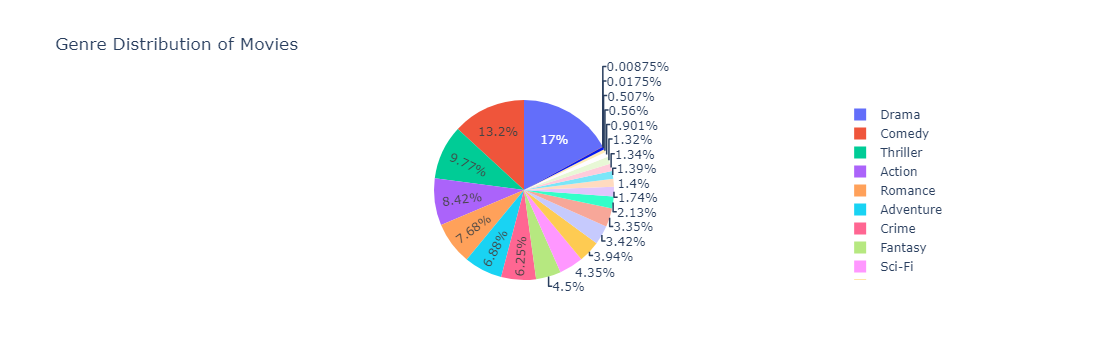

In [6]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("IMDB_Movies.csv", encoding='windows-1252')
data = df.copy()

# Split genres and count occurrences
# Assuming genres are separated by '|'
all_genres = df['genres'].str.split('|').explode().value_counts()

# Convert to a DataFrame for Plotly
genre_counts = all_genres.reset_index()
genre_counts.columns = ['Genre', 'Count']

# Plot the pie chart
fig = px.pie(genre_counts, values='Count', names='Genre', title='Genre Distribution of Movies')
fig.show()


Mean Duration: 109.92179786957651
Median Duration: 106.0
Standard Deviation of Duration: 22.75114776958191


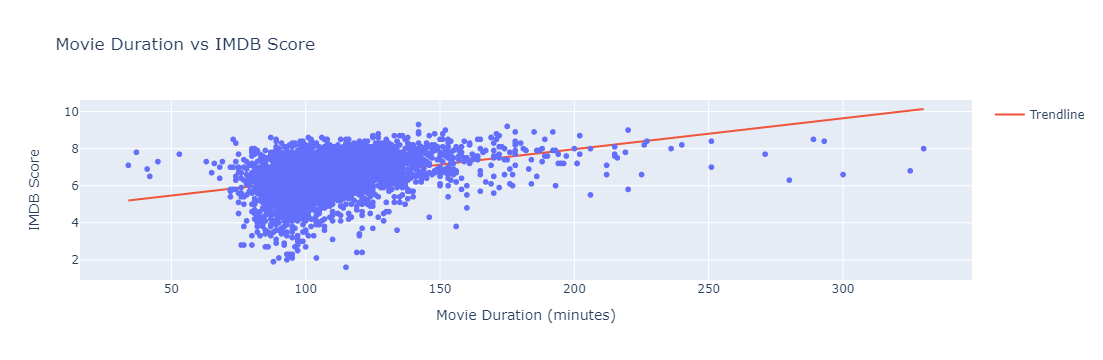

In [8]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np


# Filter necessary columns
df2 = df[['duration', 'imdb_score']].dropna()

# Calculate Descriptive Statistics
mean_duration = df2['duration'].mean()
median_duration = df2['duration'].median()
std_duration = df2['duration'].std()

print(f"Mean Duration: {mean_duration}")
print(f"Median Duration: {median_duration}")
print(f"Standard Deviation of Duration: {std_duration}")

# Create a scatter plot
fig = px.scatter(df2, x='duration', y='imdb_score', title='Movie Duration vs IMDB Score',
                 labels={'duration': 'Movie Duration (minutes)', 'imdb_score': 'IMDB Score'})

# Add a trendline
# Calculate the trendline
z = np.polyfit(df2['duration'], df2['imdb_score'], 1)
p = np.poly1d(z)

# Add trendline to the figure
fig.add_trace(go.Scatter(x=df2['duration'], y=p(df2['duration']), mode='lines', name='Trendline'))

# Show the plot
fig.show()


In [9]:
# Filter necessary columns and drop rows with missing values in 'language' or 'imdb_score'
df3 = df[['language', 'imdb_score']].dropna()

# Calculate the number of movies for each language
language_counts = df3['language'].value_counts()

# Calculate mean, median, and standard deviation of IMDB scores for each language
language_stats = df3.groupby('language')['imdb_score'].agg(['mean', 'median', 'std'])

# Combine counts with stats
language_analysis = language_stats.join(language_counts.rename('count'))

# Display the results
# print(language_analysis)



In [16]:
df = data.copy()



# Data Cleaning
df['budget'] = df['budget'].replace('[\$,]', '', regex=True).astype(float)
df['gross'] = df['gross'].replace('[\$,]', '', regex=True).astype(float)

# Handling missing values
df['content_rating'].fillna('Not Rated', inplace=True)
df['budget'].fillna(df['budget'].median(), inplace=True)
df['gross'].fillna(df['gross'].median(), inplace=True)

# Preprocessing
df['genres'] = df['genres'].str.split('|')
df = df.explode('genres')




# Preprocessing
# Handling missing values
df['budget'] = df['budget'].fillna(df['budget'].median())
df['content_rating'] = df['content_rating'].fillna('Unrated')
df = df.dropna(subset=['director_name', 'imdb_score'])



In [18]:
# Task C: Language Analysis
# Count the number of movies for each language
language_counts = df['language'].value_counts().reset_index()
language_counts.columns = ['Language', 'Count']
language_counts

,Language,Count
0,English,10926
1,French,109
2,Spanish,66
3,Mandarin,48
4,Japanese,42
5,German,35
6,Cantonese,23
7,Hindi,22
8,Korean,16
9,Italian,15


In [20]:
# Calculate mean, median, and standard deviation of IMDB scores for each language
language_stats = df.groupby('language')['imdb_score'].agg(['mean', 'median', 'std']).reset_index()
language_stats.columns = ['Language', 'Mean_IMDB_Score', 'Median_IMDB_Score', 'Std_Dev_IMDB_Score']
language_stats

,Language,Mean_IMDB_Score,Median_IMDB_Score,Std_Dev_IMDB_Score
0,Aboriginal,7.028571,7.50,0.587975
1,Arabic,7.200000,7.20,0.000000
2,Aramaic,7.100000,7.10,NaN
3,Bosnian,4.300000,4.30,0.000000
4,Cantonese,7.300000,7.30,0.389639
5,Czech,7.400000,7.40,0.000000
6,Danish,7.600000,7.30,0.469042
7,Dari,7.500000,7.50,0.141421
8,Dutch,7.566667,7.80,0.350000
9,Dzongkha,7.500000,7.50,0.000000


In [26]:
# Merge language counts with statistics
language_analysis = pd.merge(language_counts, language_stats, on='Language')
language_analysis

,Language,Count,Mean_IMDB_Score,Median_IMDB_Score,Std_Dev_IMDB_Score
0,English,10926,6.422250,6.50,1.034884
1,French,109,7.300000,7.20,0.543650
2,Spanish,66,7.077273,7.20,0.825329
3,Mandarin,48,7.006250,7.25,0.745884
4,Japanese,42,7.571429,7.70,0.889309
5,German,35,7.711429,7.70,0.599888
6,Cantonese,23,7.300000,7.30,0.389639
7,Hindi,22,6.959091,7.30,1.024769
8,Korean,16,7.631250,7.50,0.546161
9,Italian,15,6.813333,6.90,1.161813


In [28]:
# Task D: Director Analysis
# Calculate the average IMDB score for each director
director_stats = df.groupby('director_name')['imdb_score'].mean().reset_index()
director_stats.columns = ['Director', 'Average_IMDB_Score']
director_stats

,Director,Average_IMDB_Score
0,Aaron Schneider,7.100000
1,Aaron Seltzer,2.700000
2,Abel Ferrara,6.600000
3,Adam Carolla,6.100000
4,Adam Goldberg,5.400000
...,...,...
1742,Zack Snyder,7.239286
1743,Zak Penn,6.600000
1744,Zal Batmanglij,6.900000
1745,Álex de la Iglesia,6.100000


In [30]:
# Calculate the 90th percentile for directors' average IMDB scores
percentile_90 = director_stats['Average_IMDB_Score'].quantile(0.90)
percentile_90

7.5

In [32]:
# Identify top directors based on the 90th percentile
top_directors = director_stats[director_stats['Average_IMDB_Score'] >= percentile_90]
top_directors

,Director,Average_IMDB_Score
15,Akira Kurosawa,8.400000
29,Alejandro Amenábar,7.590000
30,Alejandro G. Iñárritu,7.927273
34,Alex Garland,7.700000
35,Alex Gibney,7.700000
...,...,...
1725,William H. Macy,7.500000
1728,William Wyler,8.100000
1730,Wolfgang Becker,7.700000
1737,Yash Chopra,7.500000


In [34]:
# Task E: Budget Analysis
# Calculate correlation between budget and gross earnings
correlation = df[['budget', 'gross']].corr().iloc[0, 1]
correlation

0.09057935256429434

In [36]:
# Calculate the profit margin for each movie
df['profit_margin'] = df['gross'] - df['budget']
df

,director_name,num_critic_for_reviews,duration,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,...,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,movie_facebook_likes,Unnamed: 21,Unnamed: 22,profit_margin
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Action,CCH Pounder,Avatar,"8,86,204",...,USA,PG-13,237000000.0,2009,936,7.9,"33,000",NaN,NaN,523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Adventure,CCH Pounder,Avatar,"8,86,204",...,USA,PG-13,237000000.0,2009,936,7.9,"33,000",NaN,NaN,523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Fantasy,CCH Pounder,Avatar,"8,86,204",...,USA,PG-13,237000000.0,2009,936,7.9,"33,000",NaN,NaN,523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Sci-Fi,CCH Pounder,Avatar,"8,86,204",...,USA,PG-13,237000000.0,2009,936,7.9,"33,000",NaN,NaN,523505847.0
1,Gore Verbinski,302,169,Orlando Bloom,"40,000",309404152.0,Action,Johnny Depp,Pirates of the Caribbean: At World's End,"4,71,220",...,USA,PG-13,300000000.0,2007,"5,000",7.1,0,NaN,NaN,9404152.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3846,Robert Rodriguez,56,81,Peter Marquardt,121,2040920.0,Romance,Carlos Gallardo,El Mariachi,"52,055",...,USA,R,7000.0,1992,20,6.9,0,NaN,NaN,2033920.0
3846,Robert Rodriguez,56,81,Peter Marquardt,121,2040920.0,Thriller,Carlos Gallardo,El Mariachi,"52,055",...,USA,R,7000.0,1992,20,6.9,0,NaN,NaN,2033920.0
3847,Edward Burns,14,95,Caitlin FitzGerald,296,4584.0,Comedy,Kerry Bishé,Newlyweds,"1,338",...,USA,Unrated,9000.0,2011,205,6.4,413,NaN,NaN,-4416.0
3847,Edward Burns,14,95,Caitlin FitzGerald,296,4584.0,Drama,Kerry Bishé,Newlyweds,"1,338",...,USA,Unrated,9000.0,2011,205,6.4,413,NaN,NaN,-4416.0


In [49]:
# Identify the movies with the highest profit margin
top_profit_movies = df.sort_values(by='profit_margin', ascending=False).head(10)
top_profit_movies.drop(columns=['Unnamed: 21', 'Unnamed: 22'], axis = 1, inplace = True)
top_profit_movies

,director_name,num_critic_for_reviews,duration,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,movie_facebook_likes,profit_margin
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Action,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Fantasy,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Sci-Fi,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Adventure,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Thriller,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Sci-Fi,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Adventure,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Action,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
25,James Cameron,315,194,Kate Winslet,"29,000",658672302.0,Romance,Leonardo DiCaprio,Titanic,"7,93,059",...,"2,528",English,USA,PG-13,200000000.0,1997,"14,000",7.7,"26,000",458672302.0
25,James Cameron,315,194,Kate Winslet,"29,000",658672302.0,Drama,Leonardo DiCaprio,Titanic,"7,93,059",...,"2,528",English,USA,PG-13,200000000.0,1997,"14,000",7.7,"26,000",458672302.0


In [40]:
# Visualizations
# Language Analysis Visualization
fig1 = px.bar(language_analysis, x='Language', y='Count', title='Number of Movies per Language')
fig2 = px.scatter(language_analysis, x='Language', y='Mean_IMDB_Score', title='Mean IMDB Score per Language')
fig3 = px.scatter(language_analysis, x='Language', y='Median_IMDB_Score', title='Median IMDB Score per Language')
fig4 = px.scatter(language_analysis, x='Language', y='Std_Dev_IMDB_Score', title='Standard Deviation of IMDB Score per Language')

# Director Analysis Visualization
fig5 = px.bar(top_directors, x='Director', y='Average_IMDB_Score', title='Top Directors by Average IMDB Score')

# Budget Analysis Visualization
fig6 = px.scatter(df, x='budget', y='gross', title=f'Correlation between Budget and Gross Earnings (r = {correlation:.2f})')
fig6.add_trace(go.Scatter(x=df['budget'], y=df['gross'], mode='markers', name='Data Points'))
fig6.add_trace(go.Scatter(x=[df['budget'].min(), df['budget'].max()], y=[df['gross'].min(), df['gross'].max()],
                         mode='lines', name='Trendline'))

# Profit Margin Visualization
fig7 = px.bar(top_profit_movies, x='movie_title', y='profit_margin', title='Top 10 Movies by Profit Margin')

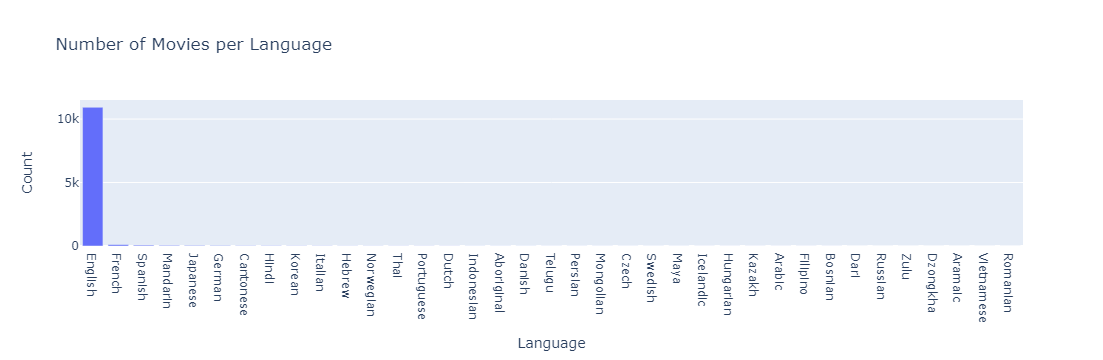

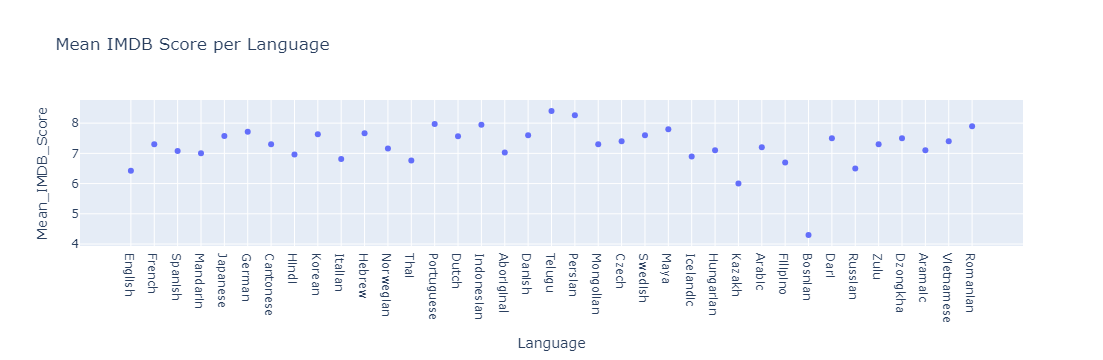

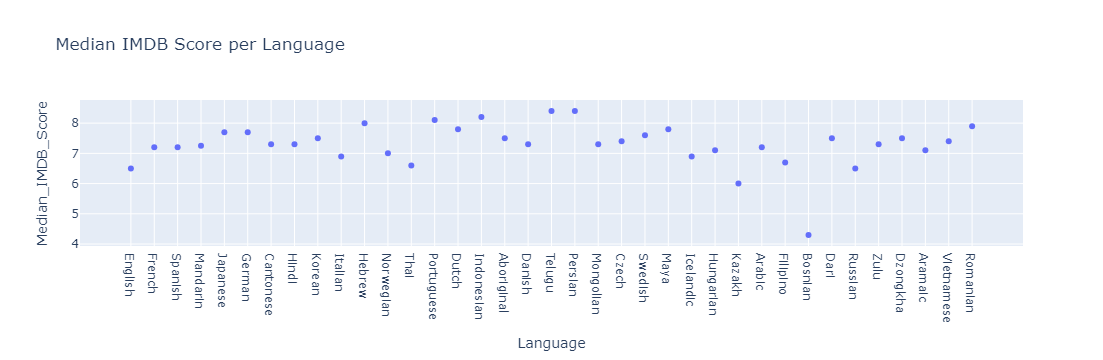

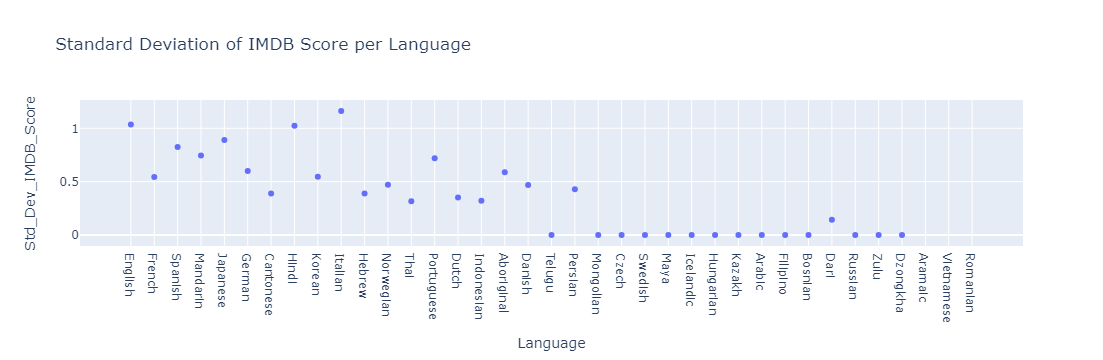

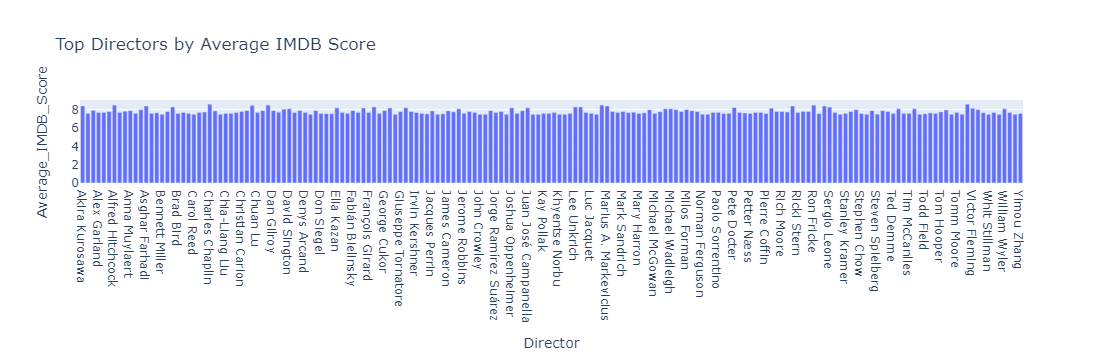

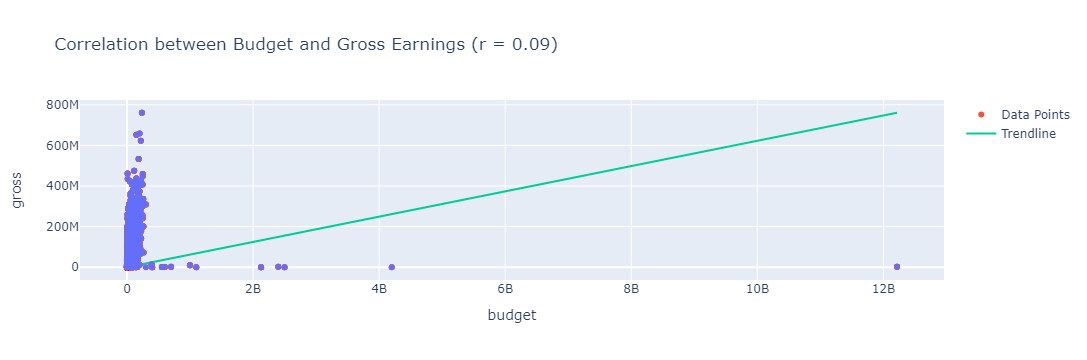

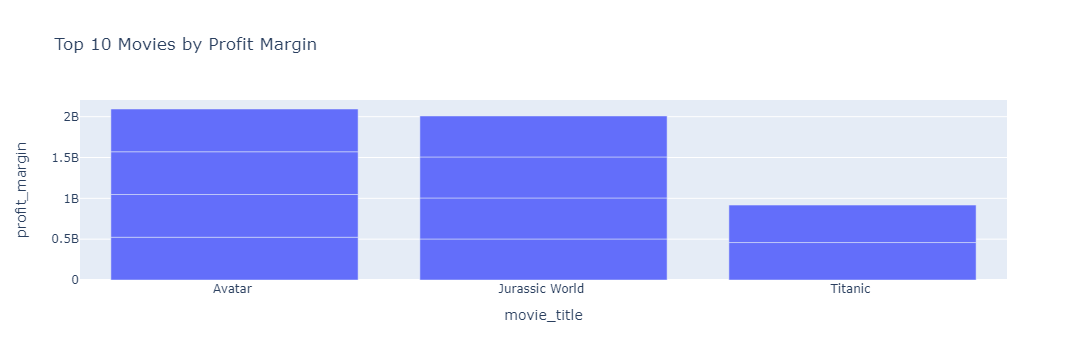

In [41]:
# Show Visualizations
fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()
fig6.show()
fig7.show()

In [42]:
# Print Insights
print("Language Analysis:")
print(language_analysis)
print("\nTop Directors by Average IMDB Score:")
print(top_directors)
print("\nBudget Analysis:")
print(f"Correlation between Budget and Gross Earnings: {correlation:.2f}")
print("Top 10 Movies by Profit Margin:")
print(top_profit_movies[['movie_title', 'profit_margin']])

Language Analysis:
      Language  Count  Mean_IMDB_Score  Median_IMDB_Score  Std_Dev_IMDB_Score
0      English  10926         6.422250               6.50            1.034884
1       French    109         7.300000               7.20            0.543650
2      Spanish     66         7.077273               7.20            0.825329
3     Mandarin     48         7.006250               7.25            0.745884
4     Japanese     42         7.571429               7.70            0.889309
5       German     35         7.711429               7.70            0.599888
6    Cantonese     23         7.300000               7.30            0.389639
7        Hindi     22         6.959091               7.30            1.024769
8       Korean     16         7.631250               7.50            0.546161
9      Italian     15         6.813333               6.90            1.161813
10      Hebrew     11         7.663636               8.00            0.388002
11   Norwegian     11         7.163636       

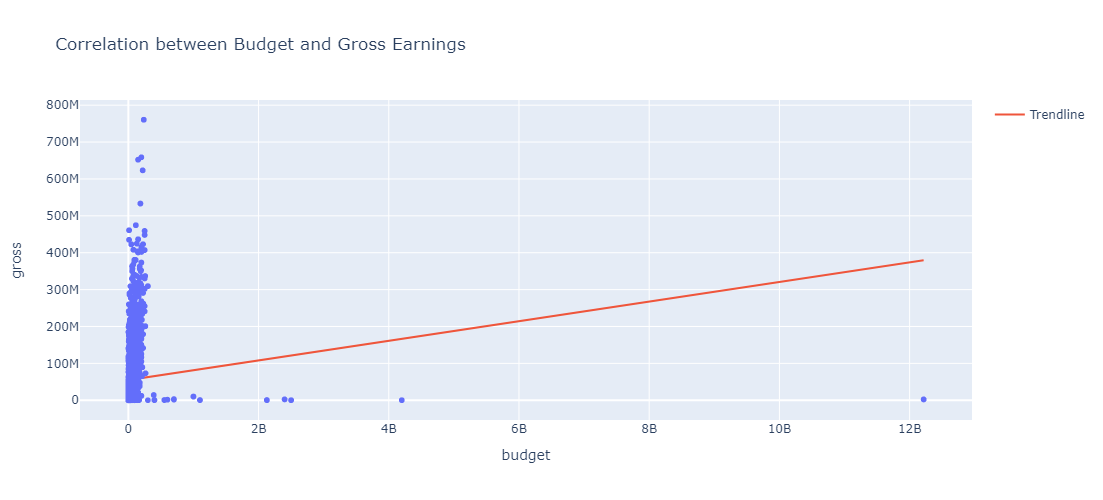

In [53]:
fig = px.scatter(df, x='budget', y='gross', title=f'Correlation between Budget and Gross Earnings', width=500, height=500)
fig.add_trace(go.Scatter(x=df['budget'], y=np.poly1d(np.polyfit(df['budget'], df['gross'], 1))(df['budget']),
                         mode='lines', name='Trendline'))
fig.show()

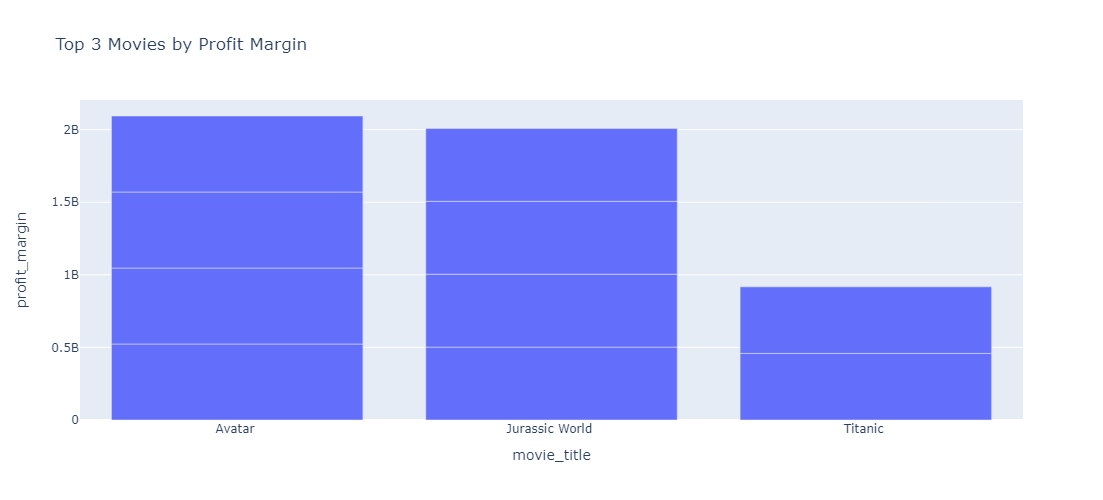

In [59]:
fig7 = px.bar(top_profit_movies, x='movie_title', y='profit_margin', title='Top 3 Movies by Profit Margin', width=500, height=500)
fig7.show()

In [57]:
top_profit_movies

,director_name,num_critic_for_reviews,duration,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,movie_facebook_likes,profit_margin
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Action,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Fantasy,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Sci-Fi,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
0,James Cameron,723,178,Joel David Moore,"1,000",760505847.0,Adventure,CCH Pounder,Avatar,"8,86,204",...,"3,054",English,USA,PG-13,237000000.0,2009,936,7.9,"33,000",523505847.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Thriller,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Sci-Fi,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Adventure,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
28,Colin Trevorrow,644,124,Judy Greer,"3,000",652177271.0,Action,Bryce Dallas Howard,Jurassic World,"4,18,214",...,"1,290",English,USA,PG-13,150000000.0,2015,"2,000",7.0,"1,50,000",502177271.0
25,James Cameron,315,194,Kate Winslet,"29,000",658672302.0,Romance,Leonardo DiCaprio,Titanic,"7,93,059",...,"2,528",English,USA,PG-13,200000000.0,1997,"14,000",7.7,"26,000",458672302.0
25,James Cameron,315,194,Kate Winslet,"29,000",658672302.0,Drama,Leonardo DiCaprio,Titanic,"7,93,059",...,"2,528",English,USA,PG-13,200000000.0,1997,"14,000",7.7,"26,000",458672302.0
